<a href="https://colab.research.google.com/github/yakdudi12/DIAO2A/blob/main/TP1_Sokoban_78.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Librerías instaladas e importadas.
Clase SokobanState definida.
Estado inicial del Sokoban:
#########      
#######.#      
#######.#####  
###         ## 
##  # # # #  ##
#  ##     ##  #
# ##  # #  ## #
#      $@$    #
####  ###  ####
####### ###    
¿Es solución? False
Heurísticas definidas.
Algoritmos de búsqueda implementados.

Ejecutando experimentos...
  BFS con N/A completado.
  BFS con N/A completado.
  DFS con N/A completado.
  DFS con N/A completado.
  Greedy con h1 completado.
  Greedy con h2 completado.
  A* con h1 completado.
  A* con h2 completado.
  IDDFS con N/A completado.
  IDDFS con N/A completado.

TABLA COMPARATIVA DE RESULTADOS
Algoritmo Heuristica Exito  Costo  Nodos Expandidos  Frontera Max  Tiempo (s)
      BFS        N/A    Si     77             60226          2342      0.5854
      BFS        N/A    Si     77             60226          2342      0.5213
      DFS        N/A    Si   2513             21943          1105      0.2962
      DFS        N/A    Si   2

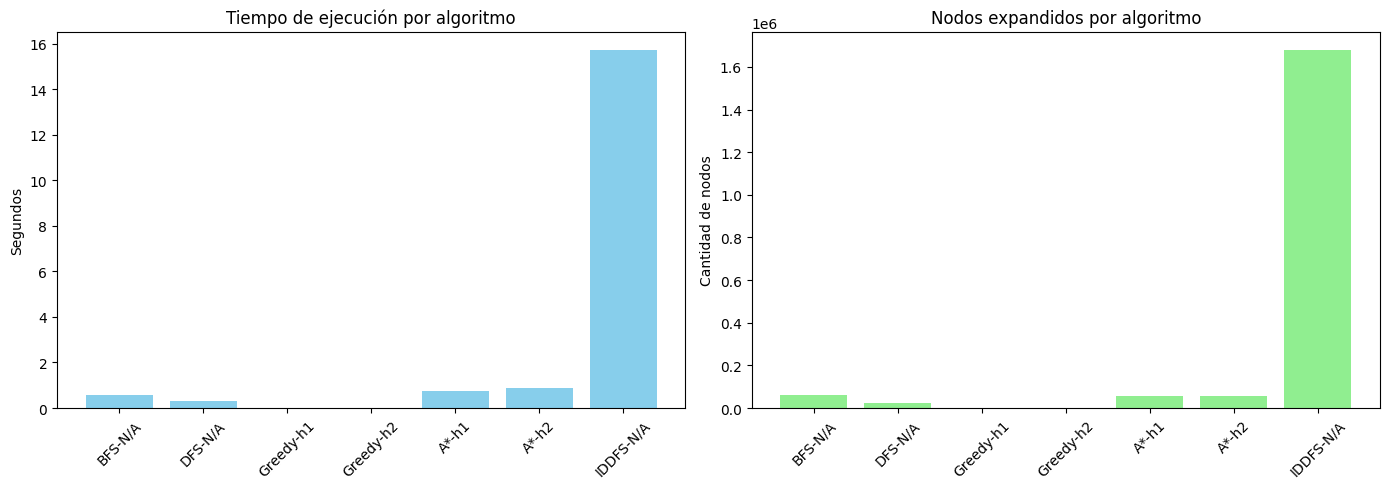

Gráficos guardados como 'graficos_comparativos.png'



Generando GIF de la solución con A* + h2...
Solución encontrada con costo 77 movimientos.
GIF guardado como 'solucion_A_estrella.gif'


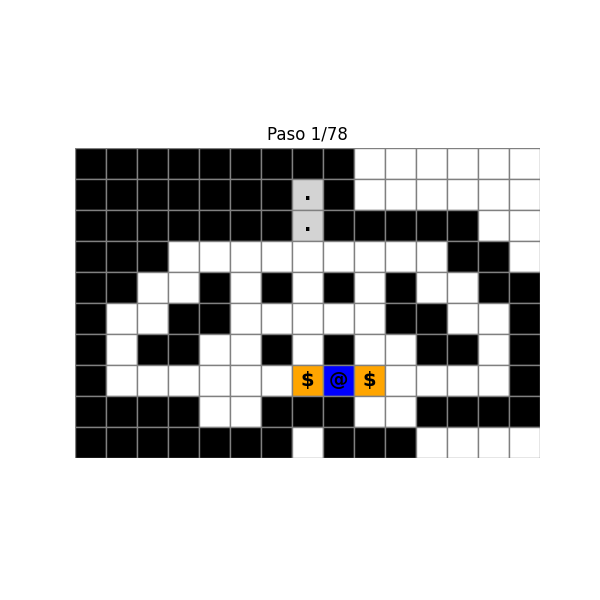


Descargando archivos generados...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


PROCESO COMPLETADO


In [ ]:
# -*- coding: utf-8 -*-
"""Sokoban - Tablero personalizado"""

get_ipython().system('pip install pillow pandas plotly -q')

try:
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.animation as animation
    from collections import deque
    import heapq
    import time
    import copy
    import pandas as pd
    from typing import Tuple, List, Set, Optional, Callable, Dict, Any
    from IPython.display import display, Image
    from google.colab import files
    import plotly.express as px
    import plotly.graph_objects as go

    print("Librerías instaladas e importadas.")
except ImportError as e:
    print("ERROR en la importacion de Librerias")

# ============================================================
# CLASE SOKOBANSTATE
# ============================================================
class SokobanState:
    """
    Representacion del estado del juego Sokoban.
    - player: (fila, columna)
    - boxes: tupla de posiciones (fila, columna) de las cajas.
    - walls: conjunto de posiciones de paredes.
    - goals: conjunto de posiciones de objetivos.
    - rows, cols: dimensiones del tablero.
    """
    def __init__(self, player: Tuple[int, int], boxes: Tuple[Tuple[int, int], ...],
                 walls: Set[Tuple[int, int]], goals: Set[Tuple[int, int]],
                 rows: int, cols: int):
        self.player = player
        self.boxes = boxes
        self.walls = walls
        self.goals = goals
        self.rows = rows
        self.cols = cols

    def __hash__(self):
        return hash((self.player, self.boxes))

    def __eq__(self, other):
        return self.player == other.player and self.boxes == other.boxes

    def is_goal(self) -> bool:
        """Verifica si todas las cajas estan en objetivos."""
        return all(box in self.goals for box in self.boxes)

    def get_successors(self) -> List[Tuple['SokobanState', str]]:
        """Genera los sucesores moviendo al jugador (o empujando una caja)."""
        successors = []
        r, c = self.player
        moves = [(-1, 0, 'U'), (1, 0, 'D'), (0, -1, 'L'), (0, 1, 'R')]

        for dr, dc, action in moves:
            nr, nc = r + dr, c + dc
            if (nr, nc) in self.walls:
                continue

            if (nr, nc) in self.boxes:
                br, bc = nr + dr, nc + dc
                if (br, bc) in self.walls or (br, bc) in self.boxes:
                    continue
                new_boxes = list(self.boxes)
                idx = new_boxes.index((nr, nc))
                new_boxes[idx] = (br, bc)
                new_boxes = tuple(new_boxes)
                successors.append((SokobanState((nr, nc), new_boxes, self.walls, self.goals, self.rows, self.cols), action + '!'))
            else:
                successors.append((SokobanState((nr, nc), self.boxes, self.walls, self.goals, self.rows, self.cols), action))
        return successors

    def __repr__(self):
        grid = [[' ' for _ in range(self.cols)] for _ in range(self.rows)]
        for (r, c) in self.walls:
            grid[r][c] = '#'
        for (r, c) in self.goals:
            if grid[r][c] == ' ':
                grid[r][c] = '.'
        for (r, c) in self.boxes:
            if (r, c) in self.goals:
                grid[r][c] = '*'
            else:
                grid[r][c] = '$'
        pr, pc = self.player
        if (pr, pc) in self.goals:
            grid[pr][pc] = '+'
        else:
            grid[pr][pc] = '@'
        return '\n'.join(''.join(row) for row in grid)

print("Clase SokobanState definida.")

# ============================================================
# CARGA DE MAPA CON PREPROCESAMIENTO PARA ESTE TABLERO
# ============================================================
def preprocess_map_for_board(map_str: str) -> str:
    """
    Convierte el mapa original (con _, G, B, P y espacios externos)
    al formato esperado por load_map_from_string:
      - '_'  -> ' '  (suelo)
      - 'G'  -> '.'  (objetivo)
      - 'B'  -> '$'  (caja)
      - 'P'  -> '@'  (jugador)
      - '#'  -> '#'  (pared)
      - cualquier otro carácter (incluidos espacios externos) -> '#'
    """
    lines = map_str.strip('\n').split('\n')
    processed = []
    for line in lines:
        # Si la línea está vacía la saltamos
        if not line.strip():
            continue
        new_line = []
        for ch in line:
            if ch == '#':
                new_line.append('#')
            elif ch == '_':
                new_line.append(' ')   # suelo
            elif ch == 'G':
                new_line.append('.')   # objetivo
            elif ch == 'B':
                new_line.append('$')   # caja
            elif ch == 'P':
                new_line.append('@')   # jugador
            else:
                new_line.append('#')   # todo lo demás (espacios) = pared
        processed.append(''.join(new_line))
    return '\n'.join(processed)

def load_map_from_string(map_str: str) -> SokobanState:
    """
    Convierte un mapa en texto a un objeto SokobanState.
    Simbolos: # pared, . objetivo, $ caja, * caja sobre objetivo,
              @ jugador, + jugador sobre objetivo.
    """
    lines = [line.rstrip('\n') for line in map_str.strip().split('\n')]
    rows = len(lines)
    cols = max(len(line) for line in lines)
    walls = set()
    goals = set()
    boxes = []
    player = None

    for r, line in enumerate(lines):
        line = line.ljust(cols)
        for c, ch in enumerate(line):
            if ch == '#':
                walls.add((r, c))
            elif ch == '.':
                goals.add((r, c))
            elif ch == '$':
                boxes.append((r, c))
            elif ch == '*':
                boxes.append((r, c))
                goals.add((r, c))
            elif ch == '@':
                player = (r, c)
            elif ch == '+':
                player = (r, c)
                goals.add((r, c))

    return SokobanState(player, tuple(boxes), walls, goals, rows, cols)

# ------------------------------------------------------------
# MAPA ESPECÍFICO DEL PROBLEMA (15x10)
# ------------------------------------------------------------
mapa_raw = """
      ###
      #G#
  #####G#####
 ##_________##
##__#_#_#_#__##
#__##_____##__#
#_##__#_#__##_#
#______BPB____#
####__###__####
   ####_###
"""

# Preprocesar y cargar
mapa_procesado = preprocess_map_for_board(mapa_raw)
initial_state = load_map_from_string(mapa_procesado)

print("Estado inicial del Sokoban:")
print(initial_state)
print("¿Es solución?", initial_state.is_goal())

# ============================================================
# HEURÍSTICAS (sin cambios)
# ============================================================
def manhattan(p1: Tuple[int, int], p2: Tuple[int, int]) -> int:
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

def h1_sum_boxes_to_goal(state: SokobanState) -> int:
    total = 0
    for box in state.boxes:
        min_dist = min(manhattan(box, goal) for goal in state.goals)
        total += min_dist
    return total

def h2_plus_player_distance(state: SokobanState) -> int:
    h1 = h1_sum_boxes_to_goal(state)
    min_player_to_box = float('inf')
    for box in state.boxes:
        if box not in state.goals:
            dist = manhattan(state.player, box)
            if dist < min_player_to_box:
                min_player_to_box = dist
    if min_player_to_box == float('inf'):
        return h1
    return h1 + min_player_to_box

def h3_non_admissible(state: SokobanState) -> int:
    return h1_sum_boxes_to_goal(state) * 2

print("Heurísticas definidas.")

# ============================================================
# ALGORITMOS DE BÚSQUEDA (sin cambios, pero aumentamos max_iter)
# ============================================================
def run_search(initial_state, algorithm: str, heuristic: Optional[Callable] = None,
               max_iter: int = 200000):
    """
    Ejecuta el algoritmo de busqueda y devuelve:
    (success, path, cost, expanded_nodes, frontier_max, elapsed_time)
    """
    start_time = time.time()
    expanded = 0
    frontier_max = 0

    if algorithm == "BFS":
        visited = set()
        frontier = deque([(initial_state, [])])
        frontier_max = 1
        while frontier and expanded < max_iter:
            state, path = frontier.popleft()
            if state.is_goal():
                return True, path, len(path), expanded, frontier_max, time.time() - start_time
            if state in visited:
                continue
            visited.add(state)
            expanded += 1
            for next_state, action in state.get_successors():
                if next_state not in visited:
                    frontier.append((next_state, path + [action]))
                    frontier_max = max(frontier_max, len(frontier))
        return False, [], 0, expanded, frontier_max, time.time() - start_time

    elif algorithm == "DFS":
        visited = set()
        frontier = [(initial_state, [])]
        frontier_max = 1
        while frontier and expanded < max_iter:
            state, path = frontier.pop()
            if state.is_goal():
                return True, path, len(path), expanded, frontier_max, time.time() - start_time
            if state in visited:
                continue
            visited.add(state)
            expanded += 1
            for next_state, action in state.get_successors():
                if next_state not in visited:
                    frontier.append((next_state, path + [action]))
                    frontier_max = max(frontier_max, len(frontier))
        return False, [], 0, expanded, frontier_max, time.time() - start_time

    elif algorithm == "Greedy":
        if heuristic is None:
            raise ValueError("Greedy necesita heuristica")
        visited = set()
        counter = 0
        heap = [(heuristic(initial_state), counter, initial_state, [])]
        frontier_max = 1
        while heap and expanded < max_iter:
            _, _, state, path = heapq.heappop(heap)
            if state.is_goal():
                return True, path, len(path), expanded, frontier_max, time.time() - start_time
            if state in visited:
                continue
            visited.add(state)
            expanded += 1
            for next_state, action in state.get_successors():
                if next_state not in visited:
                    counter += 1
                    heapq.heappush(heap, (heuristic(next_state), counter, next_state, path + [action]))
                    frontier_max = max(frontier_max, len(heap))
        return False, [], 0, expanded, frontier_max, time.time() - start_time

    elif algorithm == "A*":
        if heuristic is None:
            raise ValueError("A* necesita heuristica")
        visited = {}
        counter = 0
        heap = [(heuristic(initial_state), counter, initial_state, [], 0)]
        frontier_max = 1
        while heap and expanded < max_iter:
            f, _, state, path, g = heapq.heappop(heap)
            if state.is_goal():
                return True, path, g, expanded, frontier_max, time.time() - start_time
            if state in visited and visited[state] <= g:
                continue
            visited[state] = g
            expanded += 1
            for next_state, action in state.get_successors():
                new_g = g + 1
                if next_state not in visited or new_g < visited[next_state]:
                    counter += 1
                    h = heuristic(next_state)
                    heapq.heappush(heap, (new_g + h, counter, next_state, path + [action], new_g))
                    frontier_max = max(frontier_max, len(heap))
        return False, [], 0, expanded, frontier_max, time.time() - start_time

    elif algorithm == "IDDFS":
        def dls(state, limit, depth, path, visited_set, expanded_local):
            if state.is_goal():
                return 'success', path
            if depth == limit:
                return 'cutoff', None
            cutoff_occurred = False
            for next_state, action in state.get_successors():
                if next_state not in visited_set:
                    visited_set.add(next_state)
                    expanded_local[0] += 1
                    result, res_path = dls(next_state, limit, depth + 1, path + [action], visited_set, expanded_local)
                    if result == 'success':
                        return 'success', res_path
                    if result == 'cutoff':
                        cutoff_occurred = True
            return ('cutoff', None) if cutoff_occurred else ('failure', None)

        expanded = 0
        frontier_max = 0
        for depth in range(max_iter):
            visited_set = {initial_state}
            expanded_local = [expanded]
            result, path = dls(initial_state, depth, 0, [], visited_set, expanded_local)
            expanded = expanded_local[0]
            frontier_max = max(frontier_max, depth + 1)
            if result == 'success':
                return True, path, len(path), expanded, frontier_max, time.time() - start_time
        return False, [], 0, expanded, frontier_max, time.time() - start_time

    else:
        raise ValueError(f"Algoritmo desconocido: {algorithm}")

print("Algoritmos de búsqueda implementados.")

# ============================================================
# EXPERIMENTACIÓN COMPLETA
# ============================================================
algoritmos = ["BFS", "DFS", "Greedy", "A*", "IDDFS"]
heuristicas = {
    "h1": h1_sum_boxes_to_goal,
    "h2": h2_plus_player_distance
}

resultados = []
print("\nEjecutando experimentos...")
for alg in algoritmos:
    for h_name, h_func in heuristicas.items():
        if alg in ["BFS", "DFS", "IDDFS"]:
            success, path, cost, expanded, frontier, elapsed = run_search(
                initial_state, alg, max_iter=200000
            )
            h_name_used = "N/A"
        else:
            success, path, cost, expanded, frontier, elapsed = run_search(
                initial_state, alg, heuristic=h_func, max_iter=200000
            )
            h_name_used = h_name

        resultados.append({
            "Algoritmo": alg,
            "Heuristica": h_name_used,
            "Exito": "Si" if success else "No",
            "Costo": cost if success else "-",
            "Nodos Expandidos": expanded,
            "Frontera Max": frontier,
            "Tiempo (s)": round(elapsed, 4)
        })
        print(f"  {alg} con {h_name_used} completado.")

df = pd.DataFrame(resultados)
print("\n" + "="*80)
print("TABLA COMPARATIVA DE RESULTADOS")
print("="*80)
print(df.to_string(index=False))

df.to_csv('resultados_tp1.csv', index=False)
print("\nResultados guardados en 'resultados_tp1.csv'")

# ============================================================
# GRÁFICOS ESTÁTICOS (Matplotlib)
# ============================================================
filtered = [r for r in resultados if r['Exito'] == 'Si']
if filtered:
    algs_filtered = [f"{r['Algoritmo']}-{r['Heuristica']}" for r in filtered]
    times_filtered = [r['Tiempo (s)'] for r in filtered]
    nodes_filtered = [r['Nodos Expandidos'] for r in filtered]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.bar(algs_filtered, times_filtered, color='skyblue')
    ax1.set_title('Tiempo de ejecución por algoritmo')
    ax1.set_ylabel('Segundos')
    ax1.tick_params(axis='x', rotation=45)

    ax2.bar(algs_filtered, nodes_filtered, color='lightgreen')
    ax2.set_title('Nodos expandidos por algoritmo')
    ax2.set_ylabel('Cantidad de nodos')
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('graficos_comparativos.png', dpi=150)
    plt.show()
    print("Gráficos guardados como 'graficos_comparativos.png'")
else:
    print("Ningún algoritmo encontró solución, no se generan gráficos.")

# ============================================================
# GRÁFICOS INTERACTIVOS CON PLOTLY
# ============================================================
df_success = df[df['Exito'] == 'Si'].copy()
df_success['Costo'] = pd.to_numeric(df_success['Costo'], errors='coerce')

if not df_success.empty:
    fig_scatter = px.scatter(
        df_success,
        x='Nodos Expandidos',
        y='Tiempo (s)',
        color='Algoritmo',
        size='Costo',
        hover_data=['Heuristica'],
        title='Comparación de algoritmos: Tiempo vs Nodos Expandidos',
        labels={'Nodos Expandidos': 'Nodos expandidos', 'Tiempo (s)': 'Tiempo (segundos)'}
    )
    fig_scatter.show()

    fig_bar = px.bar(
        df_success,
        x='Algoritmo',
        y='Tiempo (s)',
        color='Heuristica',
        barmode='group',
        title='Tiempo de ejecución por algoritmo y heurística',
        labels={'Tiempo (s)': 'Tiempo (segundos)'}
    )
    fig_bar.show()

    fig_box = px.box(
        df_success,
        x='Algoritmo',
        y='Tiempo (s)',
        color='Algoritmo',
        title='Distribución de tiempos por algoritmo',
        labels={'Tiempo (s)': 'Tiempo (segundos)'}
    )
    fig_box.show()

    fig_scatter2 = px.scatter(
        df_success,
        x='Nodos Expandidos',
        y='Costo',
        color='Algoritmo',
        hover_data=['Heuristica'],
        title='Costo de solución vs Nodos expandidos',
        labels={'Nodos Expandidos': 'Nodos expandidos', 'Costo': 'Costo (movimientos)'}
    )
    fig_scatter2.show()
else:
    print("No hay soluciones exitosas para generar gráficos interactivos.")

# ============================================================
# GIF DE LA SOLUCIÓN (A* + h2)
# ============================================================
def save_solution_gif(initial_state, path, filename='solucion.gif'):
    if not path:
        print("No hay camino para generar GIF.")
        return

    states = [initial_state]
    current = initial_state
    for action in path:
        for nxt, act in current.get_successors():
            if act == action:
                current = nxt
                states.append(current)
                break

    fig, ax = plt.subplots(figsize=(6, 6))

    def render_state(state, ax):
        ax.clear()
        grid = [[' ' for _ in range(state.cols)] for _ in range(state.rows)]
        for (r, c) in state.walls:
            grid[r][c] = '#'
        for (r, c) in state.goals:
            if grid[r][c] == ' ':
                grid[r][c] = '.'
        for (r, c) in state.boxes:
            if (r, c) in state.goals:
                grid[r][c] = '*'
            else:
                grid[r][c] = '$'
        pr, pc = state.player
        if (pr, pc) in state.goals:
            grid[pr][pc] = '+'
        else:
            grid[pr][pc] = '@'

        colors = {
            ' ': 'white', '#': 'black', '.': 'lightgray',
            '$': 'orange', '*': 'gold', '@': 'blue', '+': 'cyan'
        }
        for r in range(state.rows):
            for c in range(state.cols):
                ch = grid[r][c]
                color = colors.get(ch, 'white')
                ax.add_patch(plt.Rectangle((c, -r-1), 1, 1, color=color, ec='gray'))
                ax.text(c+0.5, -r-0.5, ch, ha='center', va='center', fontsize=14, fontweight='bold')
        ax.set_xlim(0, state.cols)
        ax.set_ylim(-state.rows, 0)
        ax.set_aspect('equal')
        ax.axis('off')

    def update(frame):
        render_state(states[frame], ax)
        ax.set_title(f'Paso {frame+1}/{len(states)}')

    ani = animation.FuncAnimation(fig, update, frames=len(states), repeat=False)
    ani.save(filename, writer='pillow', fps=2)
    plt.close()
    print(f"GIF guardado como '{filename}'")

print("\nGenerando GIF de la solución con A* + h2...")
success, path, cost, expanded, frontier, elapsed = run_search(
    initial_state, "A*", heuristic=h2_plus_player_distance, max_iter=200000
)

if success:
    print(f"Solución encontrada con costo {cost} movimientos.")
    save_solution_gif(initial_state, path, 'solucion_A_estrella.gif')
    display(Image('solucion_A_estrella.gif'))
else:
    print("No se encontró solución para generar el GIF.")

# ============================================================
# DESCARGA DE ARCHIVOS
# ============================================================
print("\nDescargando archivos generados...")
try:
    files.download('solucion_A_estrella.gif')
except:
    print("No se encontró el GIF para descargar.")
try:
    files.download('resultados_tp1.csv')
except:
    print("No se encontró el CSV para descargar.")
try:
    files.download('graficos_comparativos.png')
except:
    print("No se encontró la imagen de gráficos para descargar.")

print("\n" + "="*80)
print("PROCESO COMPLETADO")
print("="*80)